In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm_notebook


In [ ]:
import random
import numpy as np
import torch
def seed_everything(seed=42):

    random.seed(seed)


    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

# Импорт данных и трансформация

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)

train = DataLoader(trainset, shuffle=True, batch_size=128, num_workers=2)

testset = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)

test = DataLoader(testset, shuffle=False, batch_size=128, num_workers=2)

#classes = trainset.classes
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(classes)
value = next(iter(test))[0]
value.shape

100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]


('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


torch.Size([128, 3, 32, 32])

# Архитектура модели(Модульный уровень)

In [ ]:
class MyNet(nn.Module):
  def __init__(self, *args, **kwargs) -> None:
    super().__init__(*args, **kwargs)
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=128, kernel_size=5)
    self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2 = nn.Conv2d(in_channels=128, out_channels=512, kernel_size=3)
    self.fc1 = nn.Linear(512*6*6,256)
    self.fc2 = nn.Linear(256, 128)
    self.fc3 = nn.Linear(128, 10)


  def forward(self, x):
    x = self.pool(nn.functional.relu(self.conv1(x)))

    x = self.pool(nn.functional.relu(self.conv2(x)))
    #print(x.shape)

    x = x.view(-1, 512*6*6)

    x = nn.functional.relu(self.fc1(x))
    x = nn.functional.relu(self.fc2(x))
    x = self.fc3(x)
    return x

device = "cuda" if torch.cuda.is_available() else "cpu"
net = MyNet().to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

net(value.to(device))


tensor([[ 0.0805, -0.0566,  0.0138,  ..., -0.0371,  0.0423,  0.0705],
        [ 0.0769, -0.0494,  0.0101,  ..., -0.0406,  0.0608,  0.0696],
        [ 0.0815, -0.0612,  0.0130,  ..., -0.0401,  0.0646,  0.0716],
        ...,
        [ 0.0813, -0.0508,  0.0038,  ..., -0.0438,  0.0458,  0.0781],
        [ 0.0841, -0.0620,  0.0055,  ..., -0.0280,  0.0460,  0.0703],
        [ 0.0819, -0.0395,  0.0267,  ..., -0.0321,  0.0447,  0.0705]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

# Обучение

/tmp/ipykernel_1747/3476138805.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for epoch in tqdm_notebook(range(10)):


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_1747/3476138805.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i, batch in enumerate(tqdm_notebook(train)):


  0%|          | 0/391 [00:00<?, ?it/s]

epoch 0 loss: 4.04


...

epoch 7 loss: 0.34


  0%|          | 0/391 [00:00<?, ?it/s]

epoch 8 loss: 0.29


  0%|          | 0/391 [00:00<?, ?it/s]

epoch 9 loss: 0.26


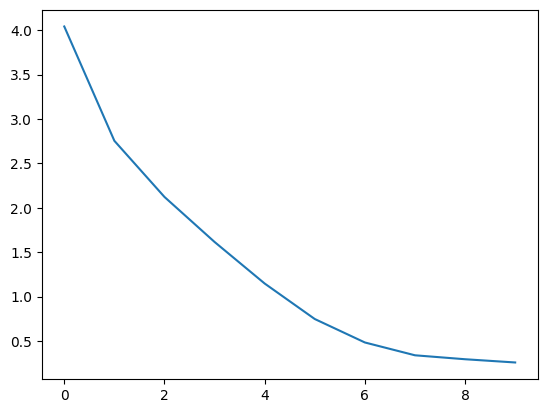

In [ ]:
loss_values = []
for epoch in tqdm_notebook(range(10)):

  loss_sum = 0
  for i, batch in enumerate(tqdm_notebook(train)):
    x_batch, y_batch = batch
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    optimizer.zero_grad()

    y_pred = net(x_batch)

    loss = loss_fn(y_pred, y_batch)
    loss_sum += loss.item()

    loss.backward()

    optimizer.step()

  loss_values.append(loss_sum/128)
  print(f"epoch {epoch} loss: {loss_values[-1]:.2f}")


plt.plot(loss_values)


# Accuracy

In [ ]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():
    for data in test:
        images, labels = data

        y_pred = net(images.to(device))#.view(4, -1))
        _, predicted = torch.max(y_pred, 1)
        c = (predicted.cpu().detach() == labels).squeeze()

        for i in range(128):
          try:
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1
          except:
            continue

k=0
for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))
    k += 100 * class_correct[i] / class_total[i]

print(f"Average Accuracy: {k/10:.2f}%")

Accuracy of airplane : 80 %
Accuracy of automobile : 87 %
Accuracy of  bird : 53 %
Accuracy of   cat : 48 %
Accuracy of  deer : 70 %
Accuracy of   dog : 68 %
Accuracy of  frog : 80 %
Accuracy of horse : 83 %
Accuracy of  ship : 83 %
Accuracy of truck : 81 %
Average Accuracy: 73.74%
